In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('diamonds_cleaned.csv')

df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53789,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53790,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53791,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53792,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [4]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='str')

### Univariate Analysis

In [5]:
num_cols = ['carat' , 'depth' , 'table' , 'price' , 'x' , 'y' , 'z']
cat_cols = ['cut', 'color', 'clarity']

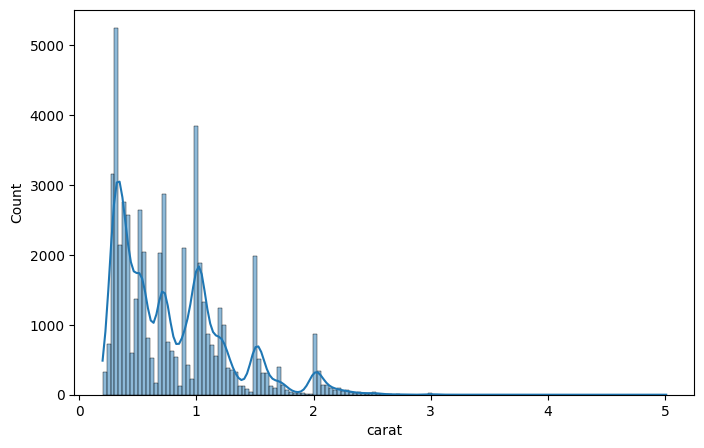

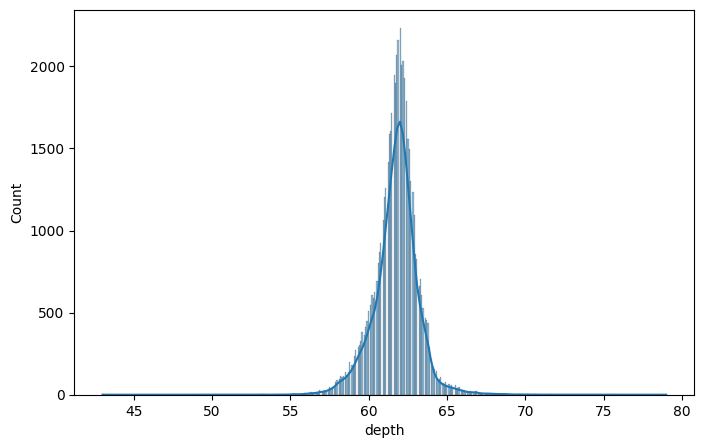

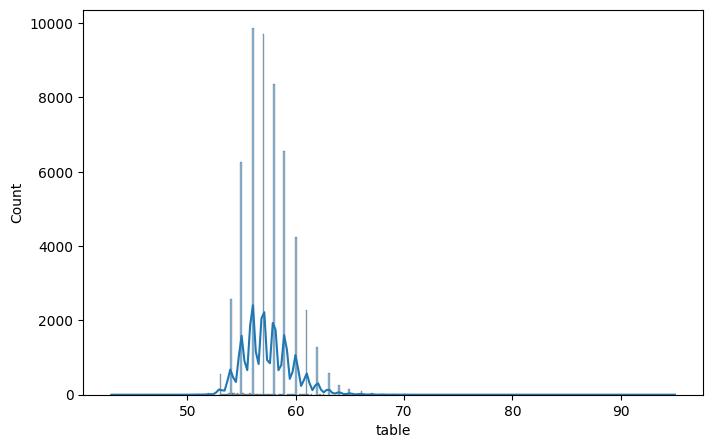

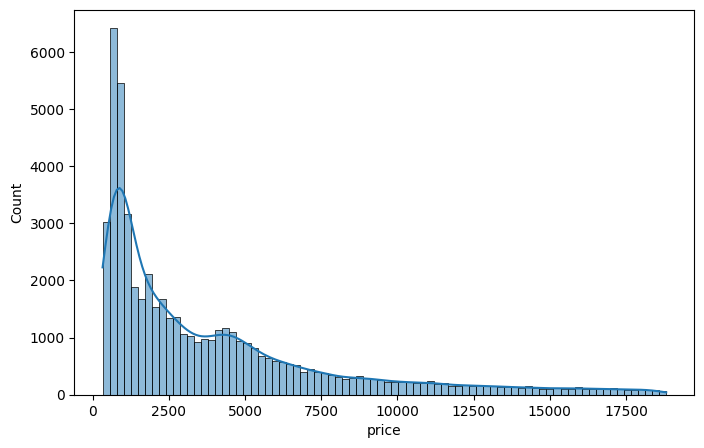

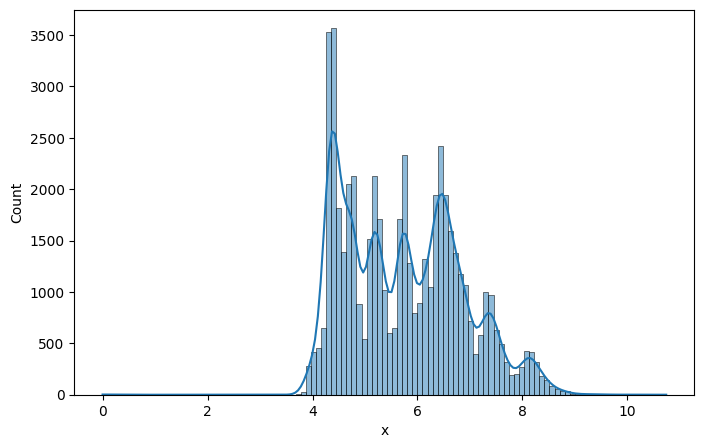

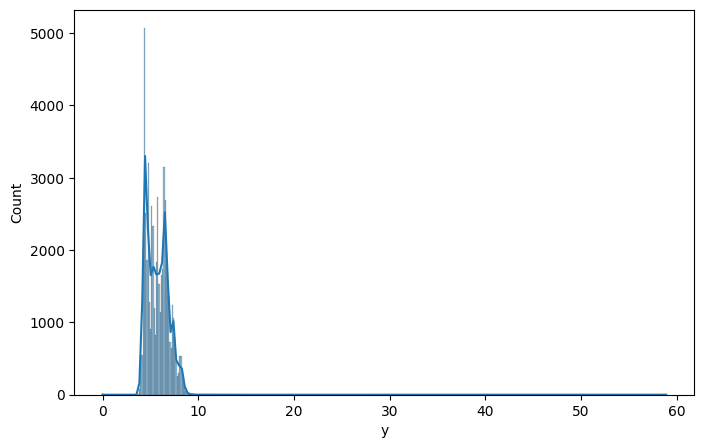

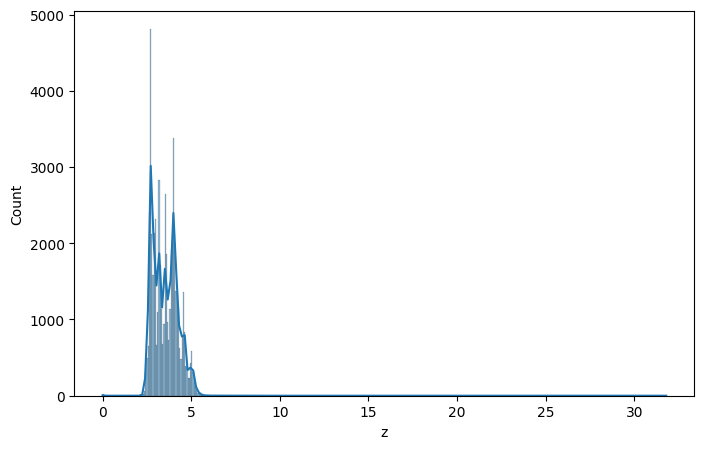

In [8]:
for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col] , kde=True)
    plt.show()

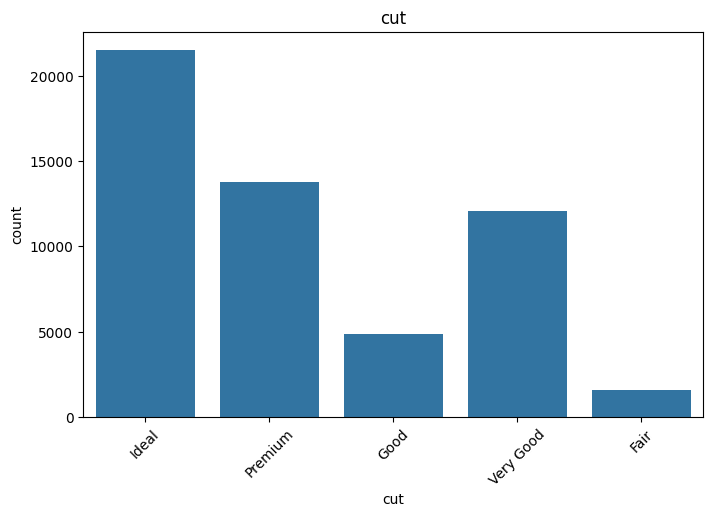

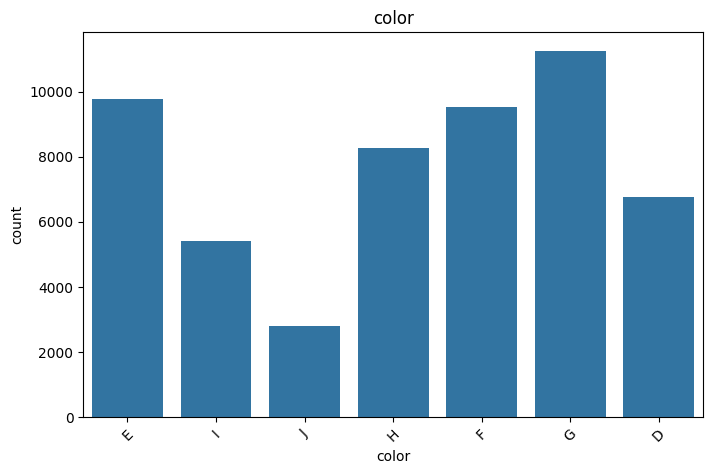

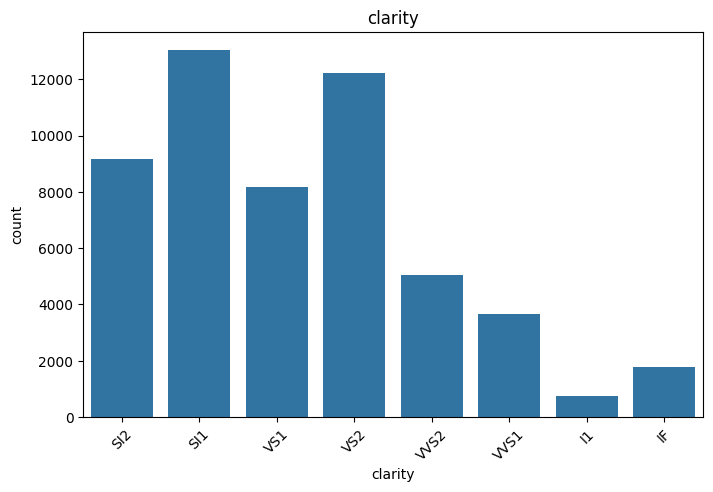

In [11]:
for col in cat_cols:  
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=45)  
    plt.show()

### Bivariate Analysis

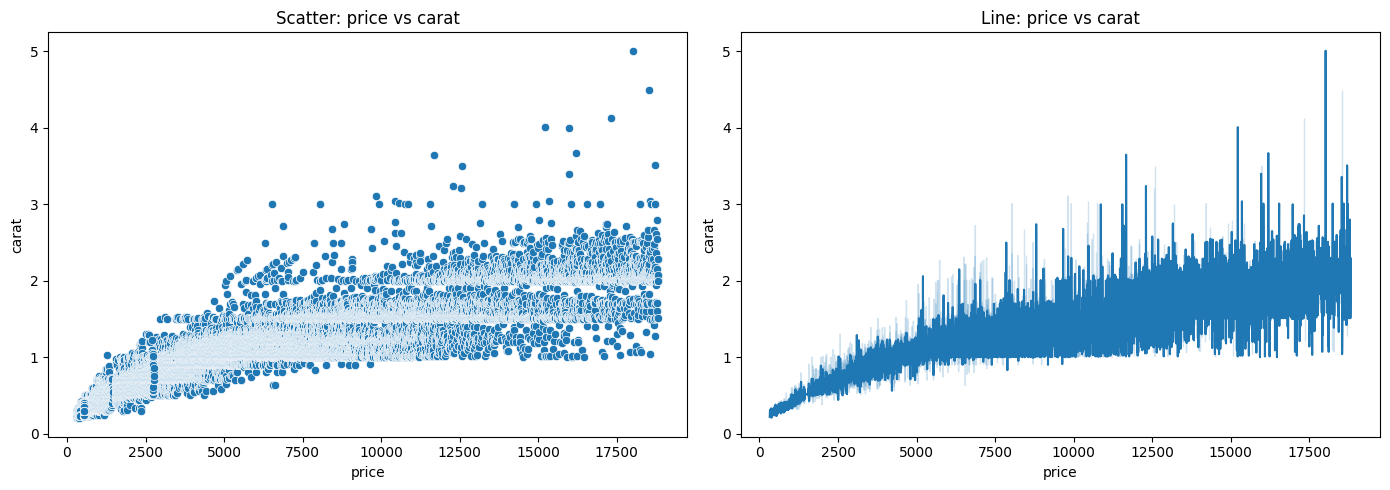

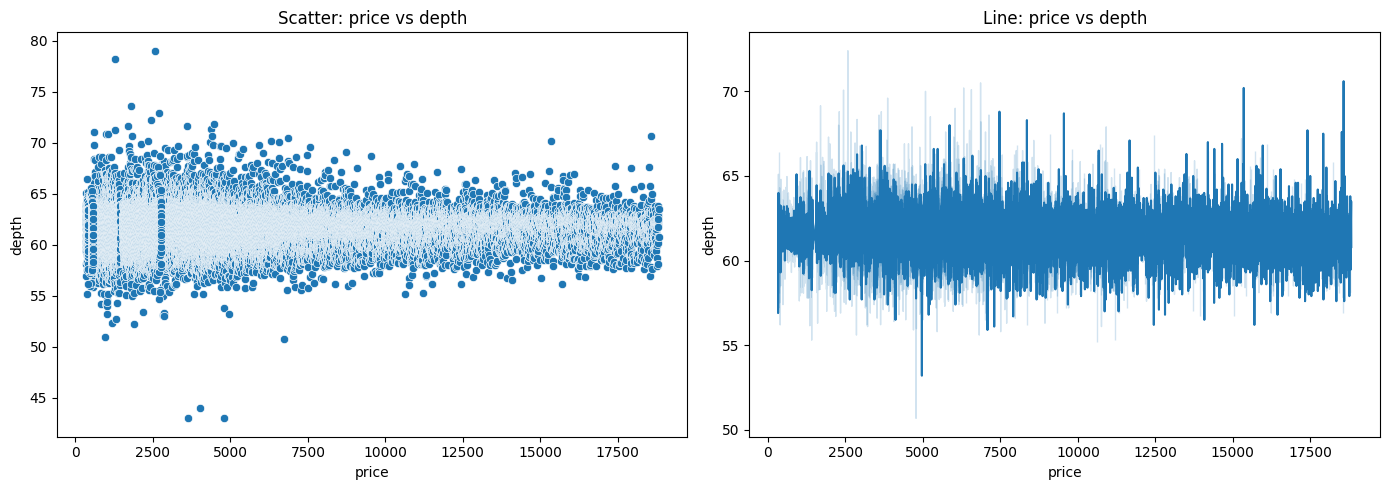

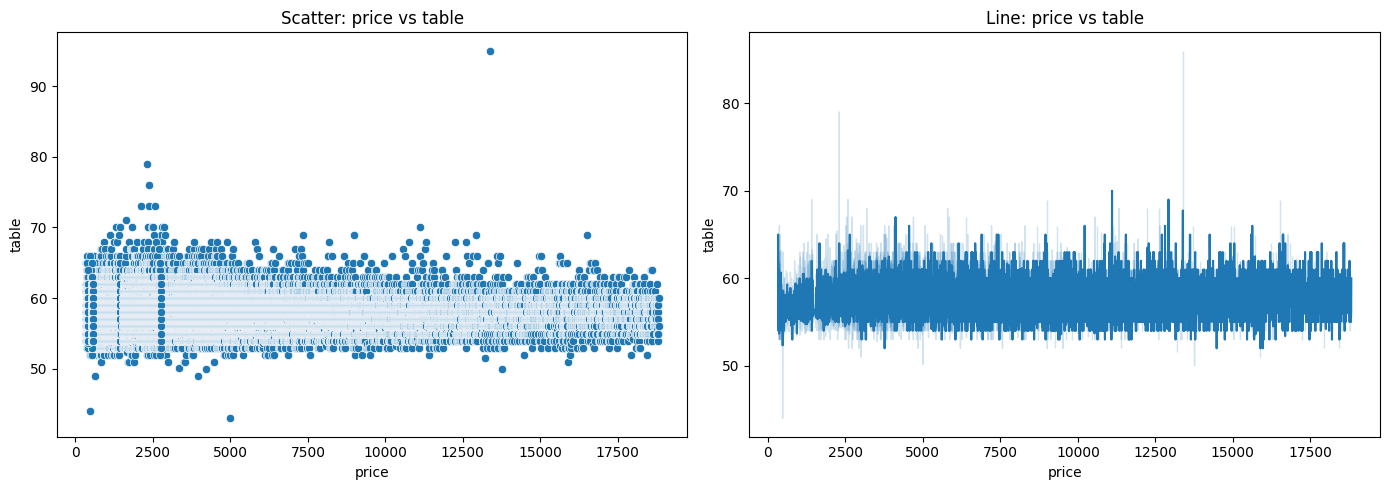

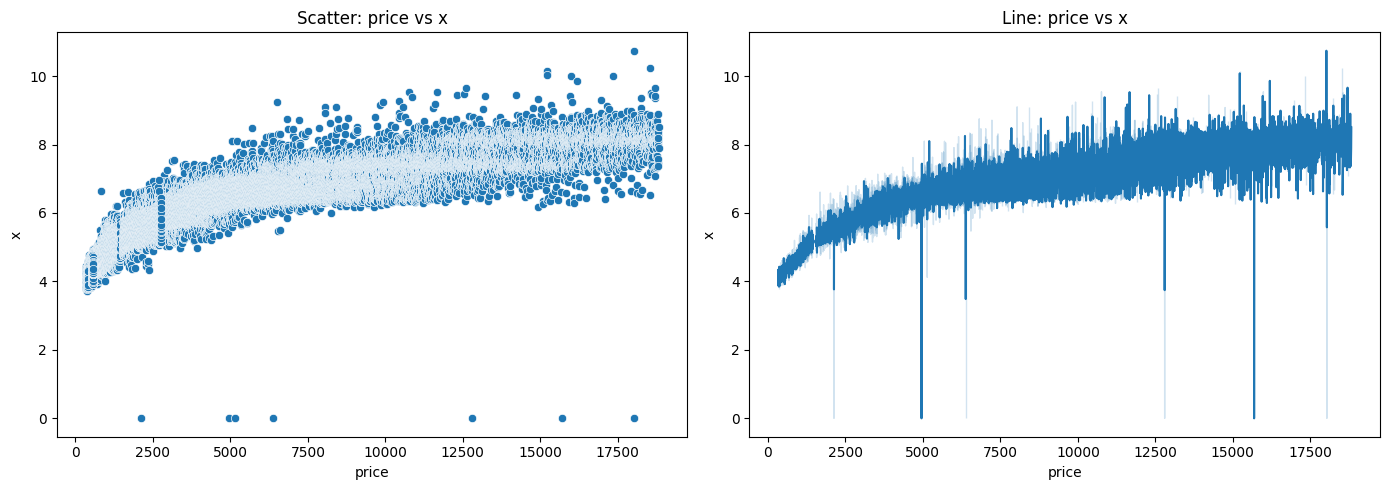

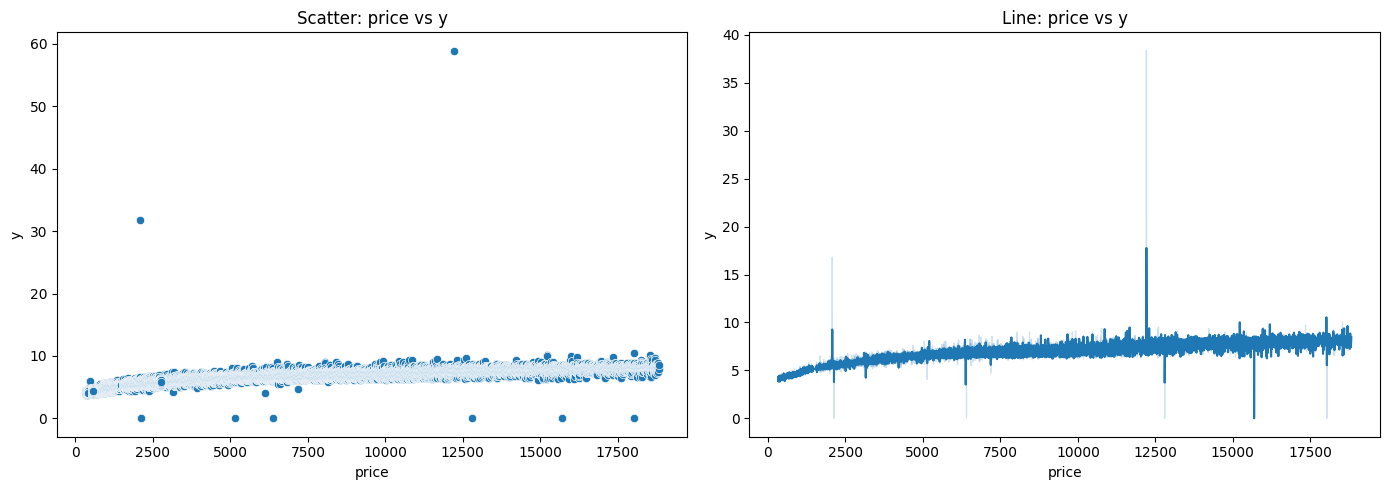

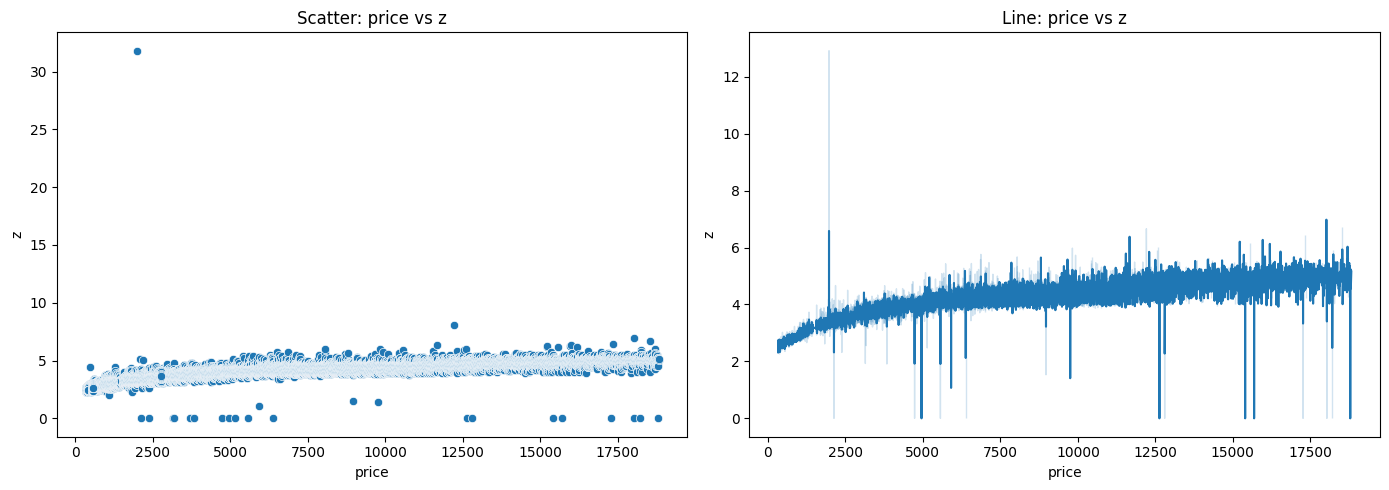

In [13]:
for col in num_cols:
    if col != 'price':
        plt.figure(figsize=(14, 5))
        
        plt.subplot(1, 2, 1)
        sns.scatterplot(data=df, x='price', y=col)
        plt.title(f'Scatter: price vs {col}')

        plt.subplot(1, 2, 2)
        sns.lineplot(data=df, x='price', y=col)
        plt.title(f'Line: price vs {col}')

        plt.tight_layout()
        plt.show()

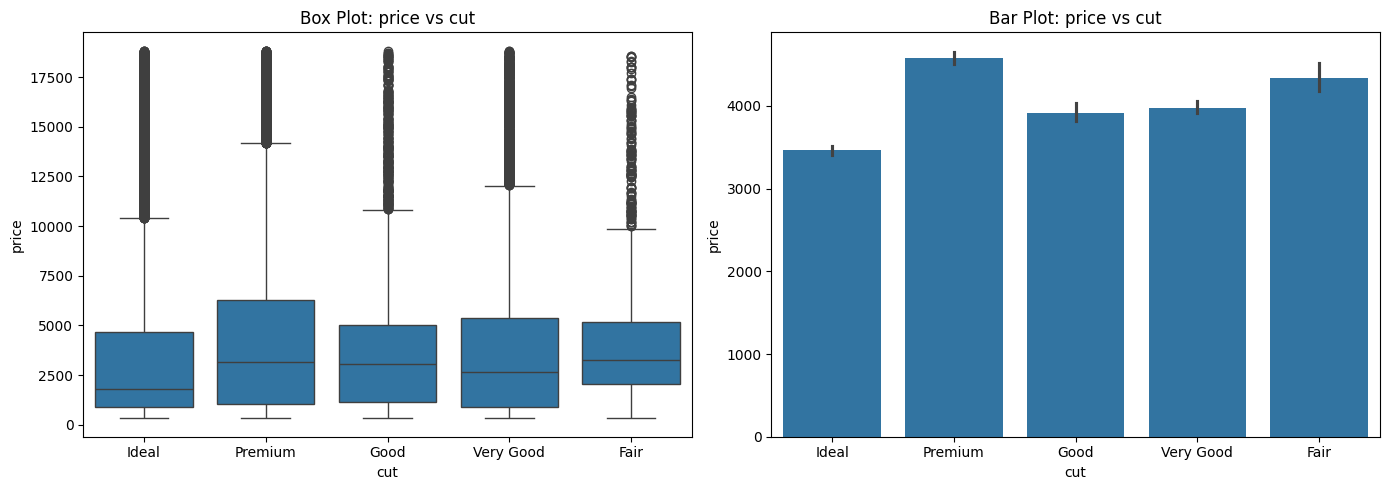

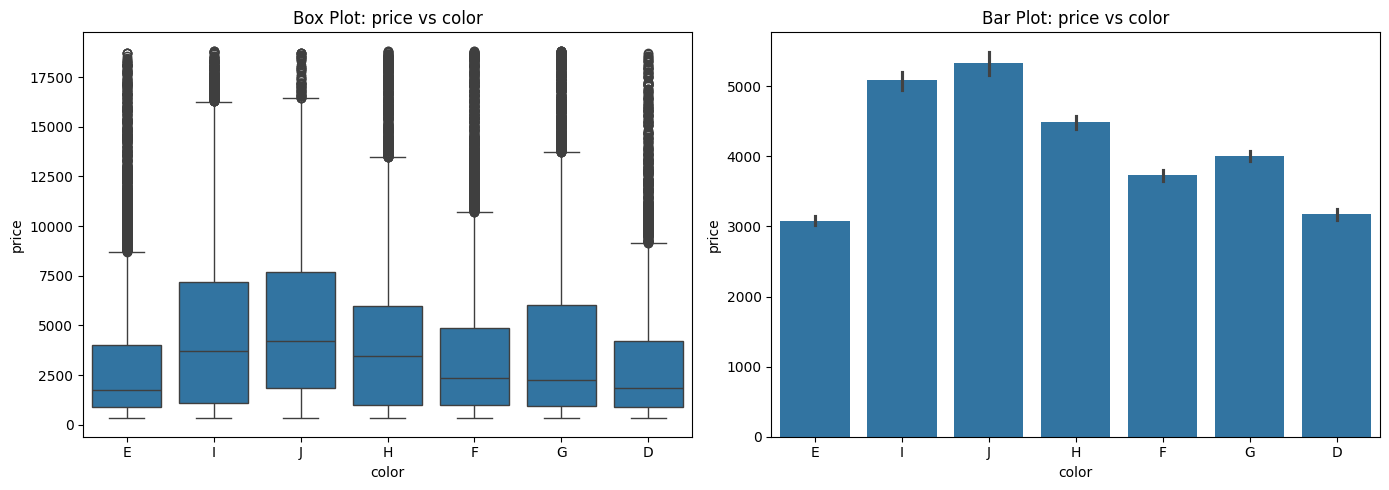

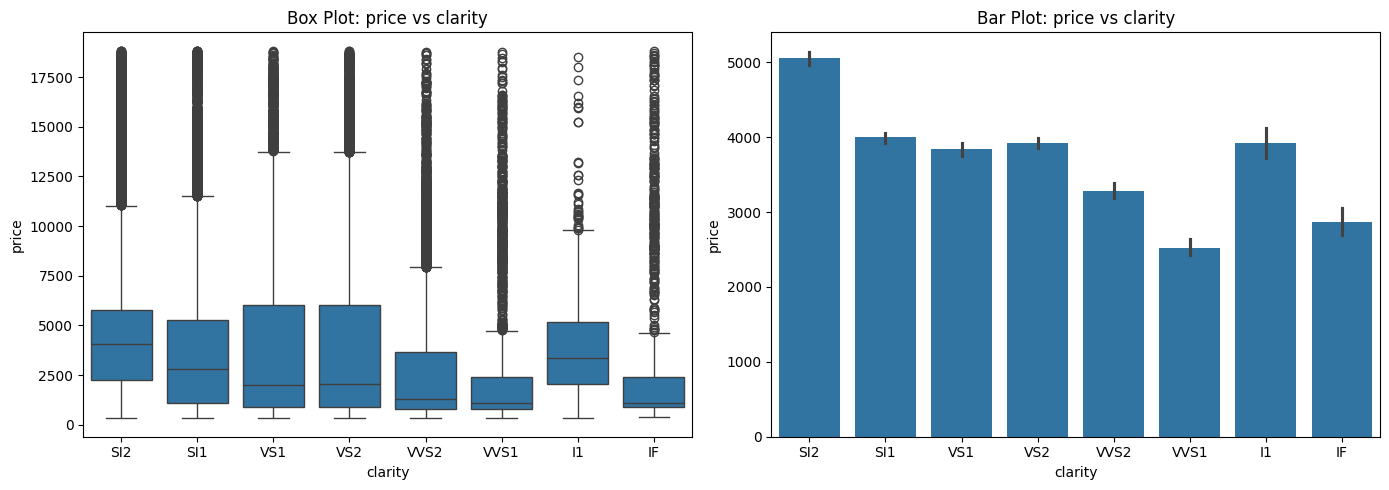

In [15]:
for col in cat_cols:
    plt.figure(figsize=(14, 5))
        
    plt.subplot(1, 2, 1)
    sns.boxplot(data=df, y='price', x=col)
    plt.title(f'Box Plot: price vs {col}')

    plt.subplot(1, 2, 2)
    sns.barplot(data=df, y='price', x=col)
    plt.title(f'Bar Plot: price vs {col}')

    plt.tight_layout()
    plt.show() 

### Feature Encoding

In [19]:
df.cut.unique()

<ArrowStringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str

In [20]:
cut_mapping = {
    'Fair': 0,
    'Good': 1,
    'Very Good': 2,
    'Premium': 3,
    'Ideal': 4
}

df['cut'] = df['cut'].map(cut_mapping)

In [22]:
df.color.unique()

<ArrowStringArray>
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Length: 7, dtype: str

In [39]:
color_mapping = {
    'J' : 0 , 'I' : 1 , 'H' : 2 , 'G' : 3 , 'F' : 4 , 'E' : 5 , 'D' : 6
}

df['color'] = df['color'].map(color_mapping)

In [25]:
df.clarity.unique()

<ArrowStringArray>
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Length: 8, dtype: str

In [26]:
clarity_mapping = {
    'I1' : 0 ,'SI2' : 1 , 'SI1' : 2 , 'VS2' : 3 , 'VS1' : 4 , 'VVS2' : 5 , 'VVS1' : 6, 'IF' : 7
}

df['clarity'] = df['clarity'].map(clarity_mapping)

In [27]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4,5,1,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,5,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,5,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,1,3,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,0,1,63.3,58.0,335,4.34,4.35,2.75


In [28]:
df.to_csv('diamond_encoded.csv' , index=False)

### correlation Analysis

In [29]:
corr = df.corr()
corr

,carat,cut,color,clarity,depth,table,price,x,y,z
carat,1.000000,-0.133376,-0.291019,-0.352288,0.027861,0.181091,0.921548,0.975380,0.951908,0.953542
cut,-0.133376,1.000000,0.020162,0.188327,-0.217078,-0.433700,-0.052241,-0.124303,-0.120233,-0.147940
color,-0.291019,0.020162,1.000000,-0.025542,-0.047572,-0.026102,-0.171825,-0.269876,-0.263153,-0.267825
clarity,-0.352288,0.188327,-0.025542,1.000000,-0.067292,-0.160000,-0.146149,-0.371636,-0.358048,-0.366568
depth,0.027861,-0.217078,-0.047572,-0.067292,1.000000,-0.297669,-0.011048,-0.025348,-0.029389,0.094757
table,0.181091,-0.433700,-0.026102,-0.160000,-0.297669,1.000000,0.126566,0.194855,0.183231,0.150270
price,0.921548,-0.052241,-0.171825,-0.146149,-0.011048,0.126566,1.000000,0.884504,0.865395,0.861208
x,0.975380,-0.124303,-0.269876,-0.371636,-0.025348,0.194855,0.884504,1.000000,0.974592,0.970686
y,0.951908,-0.120233,-0.263153,-0.358048,-0.029389,0.183231,0.865395,0.974592,1.000000,0.951844
z,0.953542,-0.147940,-0.267825,-0.366568,0.094757,0.150270,0.861208,0.970686,0.951844,1.000000


<Axes: >

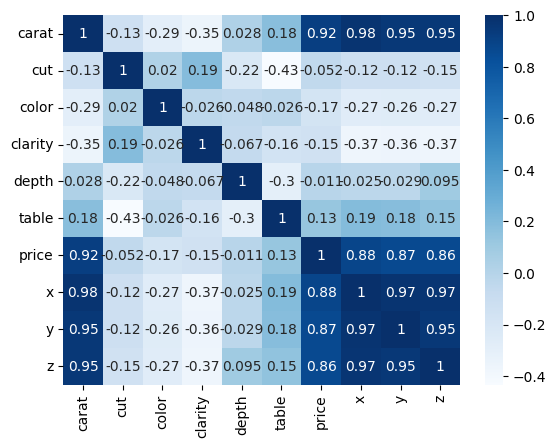

In [38]:
sns.heatmap(corr , annot=True , cmap="Blues")